In [1]:
# ================================================
# 1. Imports
# ================================================
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import pandas as pd
print('pandas version: ',pd.__version__)
pd.Int64Index = pd.Index
pd.Float64Index = pd.Index
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna


import os
from pathlib import Path

print(os.getcwd())

# Create a process data directory if it doesn't already exist
processed_data_path = Path("/Volumes/SANDISKUSBC/MLOps/hdb_price_prediction_mlops/data/processed")
mlruns_path = Path("/Volumes/SANDISKUSBC/MLOps/hdb_price_prediction_mlops/mlruns")

pandas version:  2.3.3
/Volumes/SANDISKUSBC/MLOps/hdb_price_prediction_mlops/notebooks


In [2]:
#functions

def getColTypes(df):
    categorical_cols = df[mycols].select_dtypes(include=['object']).columns
    numeric_cols = df[mycols].select_dtypes(include=['number']).columns
    return categorical_cols,numeric_cols


def setCategoryColsToDf(df,categorical_cols):
    for col in categorical_cols:
        df[col] = df[col].astype('category')
    return df




# Helper function for evaluation
def evaluate_metrics(y_true, y_pred):
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

In [3]:
train_df= pd.read_csv(processed_data_path/'featured_train.csv')
eval_df= pd.read_csv(processed_data_path/'featured_eval.csv')
hold_df= pd.read_csv(processed_data_path/'featured_hold.csv')

In [4]:
# 1. Prepare data
mycols = ['flat_type_rank', 'region_ura_rank', 'town_rank','storey_range_rank','flat_model_rank'
         ,'distance_to_cbd', 'floor_area_sqm', 'remaining_lease_years','resale_price_index']
target = 'resale_price'

In [5]:
categorical_cols,numeric_cols = getColTypes(train_df)

train_df = setCategoryColsToDf(train_df,categorical_cols)
eval_df = setCategoryColsToDf(eval_df,categorical_cols)
hold_df = setCategoryColsToDf(hold_df,categorical_cols)


# Verify the changes
print(train_df[mycols].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168869 entries, 0 to 168868
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   flat_type_rank         168869 non-null  int64  
 1   region_ura_rank        168869 non-null  int64  
 2   town_rank              168869 non-null  int64  
 3   storey_range_rank      168869 non-null  int64  
 4   flat_model_rank        168869 non-null  int64  
 5   distance_to_cbd        168869 non-null  float64
 6   floor_area_sqm         168869 non-null  float64
 7   remaining_lease_years  168869 non-null  int64  
 8   resale_price_index     168869 non-null  float64
dtypes: float64(3), int64(6)
memory usage: 11.6 MB
None


In [6]:
X_train = train_df[mycols]
y_train = train_df[target]

X_eval = eval_df[mycols]
y_eval = eval_df[target]

X_hold = hold_df[mycols]
y_hold = hold_df[target]

In [7]:
# ==============================================
# 3. Define Optuna objective function with MLflow
# ==============================================
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state": 42,
        "n_jobs": -1,
        "tree_method": "hist",
        
    }


    

    with mlflow.start_run(nested=True):
        #model = XGBRegressor(**params,enable_categorical=True)
        model = XGBRegressor(**params)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_eval)
        rmse, mae, r2 = evaluate_metrics(y_eval, y_pred)

        # Log hyperparameters + metrics
        mlflow.log_params(params)
        mlflow.log_metrics({"rmse": rmse, "mae": mae, "r2": r2})

    return rmse

In [9]:
# ==============================================
# 4. Run Optuna study with MLflow
# ==============================================
# Force MLflow to always use the root project mlruns folder

# Set MLflow experiment (Optional, creates one if it doesn't exist)
mlflow.set_experiment("hdb_xgb_optuna")
mlflow.set_tracking_uri('http://127.0.0.1:5000/')
#mlflow.set_tracking_uri(mlruns_path) # root path

#import subprocess
#subprocess.Popen(["mlflow", "ui", "--port", "5000"])

In [10]:

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=15)

print("Best params:", study.best_trial.params)

[I 2026-04-11 16:14:30,742] A new study created in memory with name: no-name-50571752-80ed-4c92-9881-14a88e29fe29
[I 2026-04-11 16:14:36,086] Trial 0 finished with value: 50757.673378303014 and parameters: {'n_estimators': 810, 'max_depth': 6, 'learning_rate': 0.18812886148006921, 'subsample': 0.7836178539616059, 'colsample_bytree': 0.9192388259253164, 'min_child_weight': 5, 'gamma': 3.890975964825288, 'reg_alpha': 0.3046917351056514, 'reg_lambda': 0.0007343324423535341}. Best is trial 0 with value: 50757.673378303014.


🏃 View run adorable-turtle-933 at: http://127.0.0.1:5000/#/experiments/981928208304289409/runs/f0c8c01c683949b9b828703713c99cf4
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/981928208304289409


[I 2026-04-11 16:14:37,540] Trial 1 finished with value: 79868.58895533203 and parameters: {'n_estimators': 306, 'max_depth': 5, 'learning_rate': 0.015121293282991399, 'subsample': 0.7306592835606793, 'colsample_bytree': 0.573804323096383, 'min_child_weight': 3, 'gamma': 0.3948147522107487, 'reg_alpha': 0.000685057551195331, 'reg_lambda': 0.0017812085134609826}. Best is trial 0 with value: 50757.673378303014.


🏃 View run nebulous-stork-952 at: http://127.0.0.1:5000/#/experiments/981928208304289409/runs/19d250b15fa64aa3a63796a3c1d1aec9
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/981928208304289409


[I 2026-04-11 16:14:40,401] Trial 2 finished with value: 51005.87615804087 and parameters: {'n_estimators': 414, 'max_depth': 8, 'learning_rate': 0.260769733589351, 'subsample': 0.5169202124257908, 'colsample_bytree': 0.9567015738112358, 'min_child_weight': 9, 'gamma': 1.8356337562577134, 'reg_alpha': 2.414232502613969e-06, 'reg_lambda': 5.439651381381601e-06}. Best is trial 0 with value: 50757.673378303014.


...

🏃 View run smiling-snake-266 at: http://127.0.0.1:5000/#/experiments/981928208304289409/runs/d74052a4cc1e4829b0a87fb79b84bfc4
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/981928208304289409


[I 2026-04-11 16:15:30,051] Trial 13 finished with value: 51921.57831900263 and parameters: {'n_estimators': 978, 'max_depth': 5, 'learning_rate': 0.09485296849902321, 'subsample': 0.8041303120732669, 'colsample_bytree': 0.9928380708459958, 'min_child_weight': 6, 'gamma': 3.638106747659106, 'reg_alpha': 0.014238722789144426, 'reg_lambda': 3.741963492137389}. Best is trial 10 with value: 50345.20956512831.


🏃 View run mercurial-grub-336 at: http://127.0.0.1:5000/#/experiments/981928208304289409/runs/4a57a88b7324402fb10975472ca5b27c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/981928208304289409


[I 2026-04-11 16:15:34,053] Trial 14 finished with value: 51880.630105997734 and parameters: {'n_estimators': 894, 'max_depth': 5, 'learning_rate': 0.12967717404847623, 'subsample': 0.6575263763985837, 'colsample_bytree': 0.8677895686700361, 'min_child_weight': 7, 'gamma': 4.9637181557700565, 'reg_alpha': 0.009087517522605884, 'reg_lambda': 0.15769991296235197}. Best is trial 10 with value: 50345.20956512831.


🏃 View run welcoming-gnat-203 at: http://127.0.0.1:5000/#/experiments/981928208304289409/runs/c90952fa2cc3402d9072fedae3615955
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/981928208304289409
Best params: {'n_estimators': 950, 'max_depth': 6, 'learning_rate': 0.18597447027443817, 'subsample': 0.7593344293906235, 'colsample_bytree': 0.9957946838061503, 'min_child_weight': 6, 'gamma': 4.847831090572198, 'reg_alpha': 0.02651261282678906, 'reg_lambda': 3.2285959079822275}


In [11]:
# ==============================================
# 5. Train final model with best params and log to MLflow
# ==============================================
best_params = study.best_trial.params
#best_model = XGBRegressor(**best_params,enable_categorical=True)
best_model = XGBRegressor(**best_params)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_eval)

rmse, mae, r2 = evaluate_metrics(y_eval, y_pred)

print("Final tuned model performance:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)
metric_df = [{'data':'eval_df','MAE':mae,'RMSE':rmse,'R²':r2,}]

from mlflow.models.signature import infer_signature
signature = infer_signature(X_train, best_model.predict(X_train))

# Log final model
with mlflow.start_run(run_name="best_xgboost_model"):
    mlflow.log_params(best_params)
    mlflow.log_metrics({"rmse": rmse, "mae": mae, "r2": r2})
    mlflow.xgboost.log_model(best_model, artifact_path="model",signature=signature)

Final tuned model performance:
MAE: 37863.429976610525
RMSE: 50595.9051478832
R²: 0.9280403445329304


/usr/local/lib/python3.9/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/04/11 16:16:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run best_xgboost_model at: http://127.0.0.1:5000/#/experiments/981928208304289409/runs/806e70134cc6414eb452ef95d9601218
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/981928208304289409


In [12]:

y_pred = best_model.predict(X_hold)
rmse, mae, r2 = evaluate_metrics(y_hold, y_pred)
hold_metric = {'data':'hold_df','MAE':mae,'RMSE':rmse,'R²':r2}
hold_metric

{'data': 'hold_df',
 'MAE': 71490.58710868425,
 'RMSE': 83276.29545868076,
 'R²': 0.829629551588088}

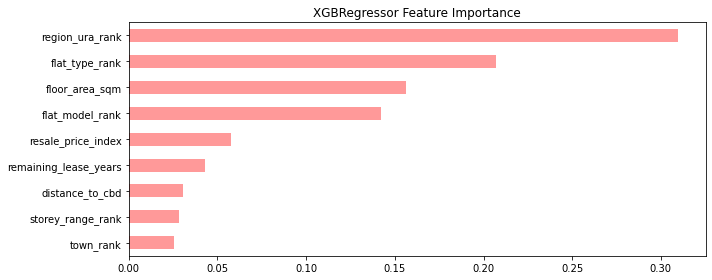

In [13]:
# Plot feature importance
plt.figure(figsize=(10, 4))
feat_imp_xgb = pd.Series(best_model.feature_importances_, index=mycols).sort_values(ascending=True)
feat_imp_xgb.plot(kind='barh', color='#ff9999')
plt.title('XGBRegressor Feature Importance')
plt.tight_layout()
plt.show()